In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('train.csv', sep="|")
df

,trustLevel,totalScanTimeInSeconds,grandTotal,lineItemVoids,scansWithoutRegistration,quantityModifications,scannedLineItemsPerSecond,valuePerSecond,lineItemVoidsPerPosition,fraud
0,5,1054,54.70,7,0,3,0.027514,0.051898,0.241379,0
1,3,108,27.36,5,2,4,0.129630,0.253333,0.357143,0
2,3,1516,62.16,3,10,5,0.008575,0.041003,0.230769,0
3,6,1791,92.31,8,4,4,0.016192,0.051541,0.275862,0
4,5,430,81.53,3,7,2,0.062791,0.189605,0.111111,0
...,...,...,...,...,...,...,...,...,...,...
1874,1,321,76.03,8,7,2,0.071651,0.236854,0.347826,0
1875,1,397,41.89,5,5,0,0.065491,0.105516,0.192308,1
1876,4,316,41.83,5,8,1,0.094937,0.132373,0.166667,0
1877,2,685,62.68,1,6,2,0.035036,0.091504,0.041667,0


In [3]:
df.dtypes

trustLevel                     int64
totalScanTimeInSeconds         int64
grandTotal                   float64
lineItemVoids                  int64
scansWithoutRegistration       int64
quantityModifications          int64
scannedLineItemsPerSecond    float64
valuePerSecond               float64
lineItemVoidsPerPosition     float64
fraud                          int64
dtype: object

Все признаки числовые

In [4]:
df.isna().sum()

trustLevel                   0
totalScanTimeInSeconds       0
grandTotal                   0
lineItemVoids                0
scansWithoutRegistration     0
quantityModifications        0
scannedLineItemsPerSecond    0
valuePerSecond               0
lineItemVoidsPerPosition     0
fraud                        0
dtype: int64

Пропусков в данных нет

In [5]:
df['fraud'].value_counts()

fraud
0    1775
1     104
Name: count, dtype: int64

In [40]:
import matplotlib.pyplot as plt

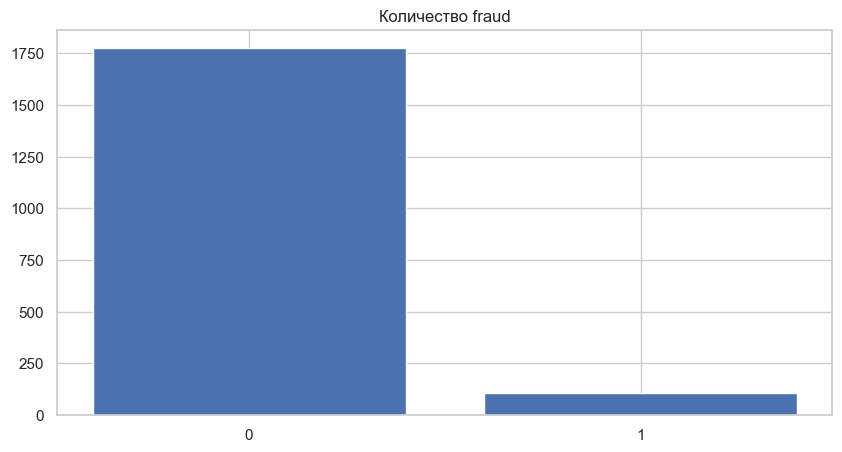

In [41]:
counts = df['fraud'].value_counts().reset_index()
plt.bar(counts['fraud'], counts['count'])
plt.title("Количество fraud")
plt.xticks([0, 1])
plt.show()

Присутствует сильный дисбаланс классов. 

In [6]:
df.describe()

,trustLevel,totalScanTimeInSeconds,grandTotal,lineItemVoids,scansWithoutRegistration,quantityModifications,scannedLineItemsPerSecond,valuePerSecond,lineItemVoidsPerPosition,fraud
count,1879.000000,1879.000000,1879.000000,1879.000000,1879.000000,1879.000000,1879.000000,1879.000000,1879.000000,1879.000000
mean,3.401809,932.153273,50.864492,5.469931,4.904204,2.525279,0.058138,0.201746,0.745404,0.055349
std,1.709404,530.144640,28.940202,3.451169,3.139697,1.695472,0.278512,1.242135,1.327241,0.228720
min,1.000000,2.000000,0.010000,0.000000,0.000000,0.000000,0.000548,0.000007,0.000000,0.000000
25%,2.000000,474.500000,25.965000,2.000000,2.000000,1.000000,0.008384,0.027787,0.160000,0.000000
50%,3.000000,932.000000,51.210000,5.000000,5.000000,3.000000,0.016317,0.054498,0.350000,0.000000
75%,5.000000,1397.000000,77.285000,8.000000,8.000000,4.000000,0.032594,0.107313,0.666667,0.000000
max,6.000000,1831.000000,99.960000,11.000000,10.000000,5.000000,6.666667,37.870000,11.000000,1.000000


In [23]:
df.duplicated().sum()

np.int64(0)

Дубликатов в данных нет

In [42]:
df.corr()

,trustLevel,totalScanTimeInSeconds,grandTotal,lineItemVoids,scansWithoutRegistration,quantityModifications,scannedLineItemsPerSecond,valuePerSecond,lineItemVoidsPerPosition,fraud
trustLevel,1.000000,0.025264,0.047656,-0.017312,0.017296,0.006506,0.030701,0.027626,0.009241,-0.319765
totalScanTimeInSeconds,0.025264,1.000000,-0.001230,0.019068,0.009066,-0.011415,-0.262988,-0.208450,-0.011623,0.110414
grandTotal,0.047656,-0.001230,1.000000,0.006321,-0.030573,-0.008163,-0.011885,0.075679,-0.008858,0.001421
lineItemVoids,-0.017312,0.019068,0.006321,1.000000,-0.017023,-0.007173,-0.004438,0.005114,0.346514,0.063496
scansWithoutRegistration,0.017296,0.009066,-0.030573,-0.017023,1.000000,0.018961,-0.024126,-0.018844,0.002834,0.074123
quantityModifications,0.006506,-0.011415,-0.008163,-0.007173,0.018961,1.000000,-0.014880,0.010548,0.018318,-0.000864
scannedLineItemsPerSecond,0.030701,-0.262988,-0.011885,-0.004438,-0.024126,-0.014880,1.000000,0.692152,-0.056316,-0.023085
valuePerSecond,0.027626,-0.208450,0.075679,0.005114,-0.018844,0.010548,0.692152,1.000000,0.019886,-0.028873
lineItemVoidsPerPosition,0.009241,-0.011623,-0.008858,0.346514,0.002834,0.018318,-0.056316,0.019886,1.000000,-0.090116
fraud,-0.319765,0.110414,0.001421,0.063496,0.074123,-0.000864,-0.023085,-0.028873,-0.090116,1.000000


In [43]:
import seaborn as sns

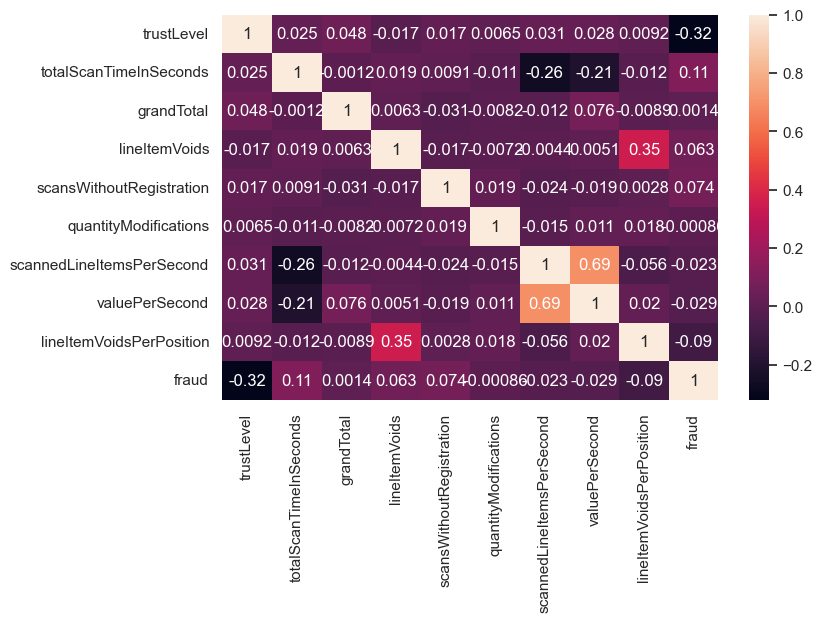

In [75]:
plt.figure(figsize=(8, 5))
sns.heatmap(df.corr(), annot=True)
plt.show()

Из корреляционной матрицы видно, что fraud - целевая переменная больше всего коррелирует с уровнем доверия. Чем ниже уровень доверия, тем выше вероятность того, что операция окажется мошеннической

Некоторые признаки коррелируют между собой, потому что являются производными

In [78]:
df.groupby('trustLevel')['fraud'].sum()

trustLevel
1    89
2    15
3     0
4     0
5     0
6     0
Name: fraud, dtype: int64

Мошенничество встречается только у людей с trustlevel 1 и 2

In [49]:
df.columns

Index(['trustLevel', 'totalScanTimeInSeconds', 'grandTotal', 'lineItemVoids',
       'scansWithoutRegistration', 'quantityModifications',
       'scannedLineItemsPerSecond', 'valuePerSecond',
       'lineItemVoidsPerPosition', 'fraud'],
      dtype='str')

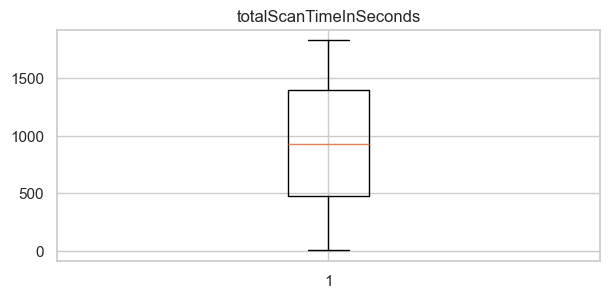

In [66]:
plt.figure(figsize=(7, 3))
plt.boxplot(df['totalScanTimeInSeconds'])
plt.title('totalScanTimeInSeconds')
plt.show()

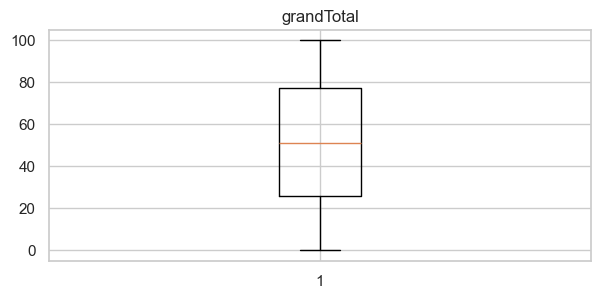

In [65]:
plt.figure(figsize=(7, 3))
plt.boxplot(df['grandTotal'])
plt.title('grandTotal')
plt.show()

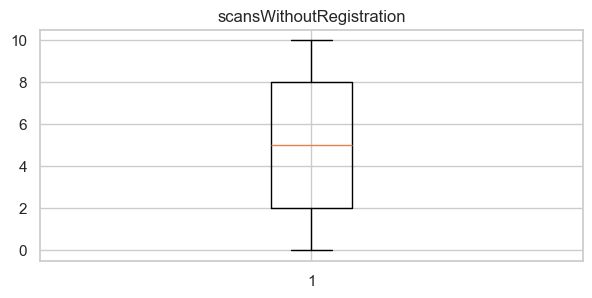

In [67]:
plt.figure(figsize=(7, 3))
plt.boxplot(df['scansWithoutRegistration'])
plt.title('scansWithoutRegistration')
plt.show()

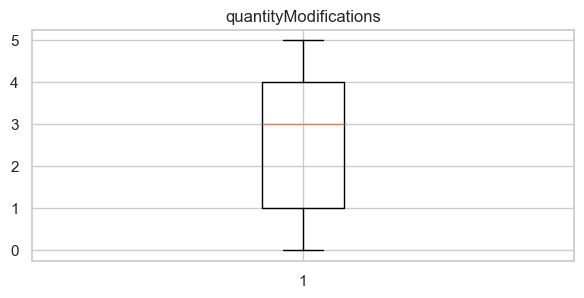

In [68]:
plt.figure(figsize=(7, 3))
plt.boxplot(df['quantityModifications'])
plt.title('quantityModifications')
plt.show()

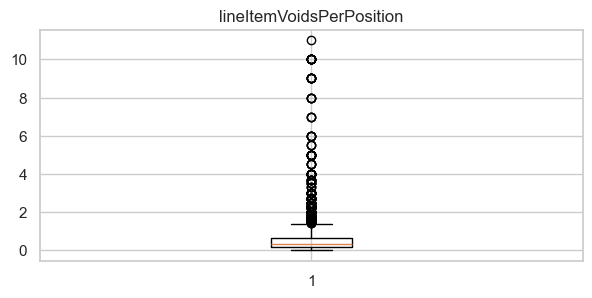

In [69]:
plt.figure(figsize=(7, 3))
plt.boxplot(df['lineItemVoidsPerPosition'])
plt.title('lineItemVoidsPerPosition')
plt.show()

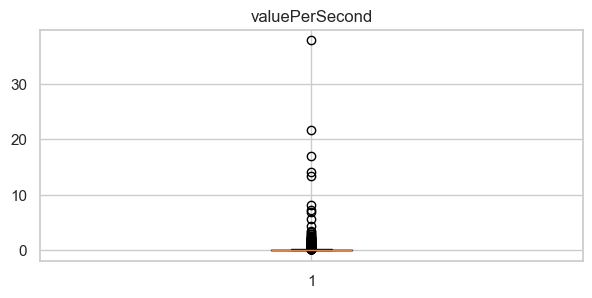

In [70]:
plt.figure(figsize=(7, 3))
plt.boxplot(df['valuePerSecond'])
plt.title('valuePerSecond')
plt.show()

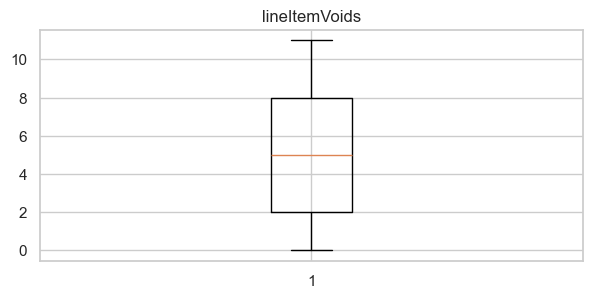

In [71]:
plt.figure(figsize=(7, 3))
plt.boxplot(df['lineItemVoids'])
plt.title('lineItemVoids')
plt.show()

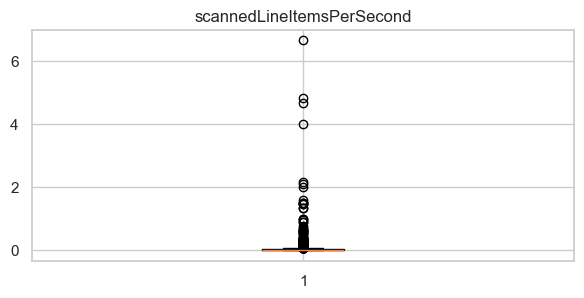

In [72]:
plt.figure(figsize=(7, 3))
plt.boxplot(df['scannedLineItemsPerSecond'])
plt.title('scannedLineItemsPerSecond')
plt.show()

Видно, что в данных имеется много выбросов в некоторых столбцах

Для нейронных сетей это является проблемой

Поэтому требуется скаллирование

In [58]:
df.groupby('fraud').mean()

,trustLevel,totalScanTimeInSeconds,grandTotal,lineItemVoids,scansWithoutRegistration,quantityModifications,scannedLineItemsPerSecond,valuePerSecond,lineItemVoidsPerPosition
fraud,,,,,,,,,
0,3.534085,917.988169,50.854541,5.416901,4.847887,2.525634,0.059693,0.210424,0.774348
1,1.144231,1173.913462,51.034327,6.375000,5.865385,2.519231,0.031582,0.053622,0.251412


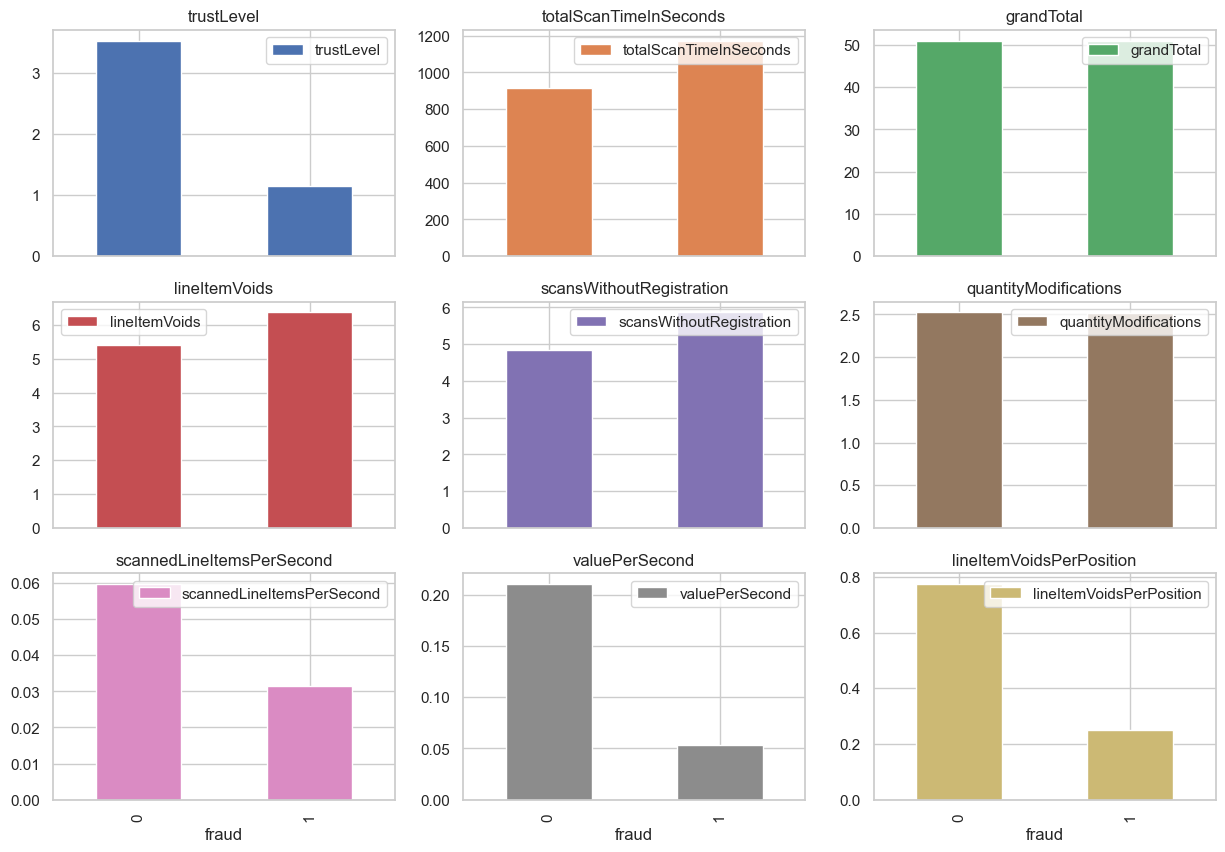

In [91]:
df.groupby('fraud').mean().plot(kind='bar', subplots=True, layout=(3, 3), figsize=(15, 10))
plt.show()